# iSPIM data — ODF Analysis
Figure 5 of the manuscript.

In [1]:
import colorsys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import navis
import numpy as np
import pyvista as pv
from fiberorient.odf import ODF
from fiberorient.util import make_sphere
from scipy.spatial import KDTree

from acanalysis.odf.plotting import plot_odf
from acanalysis.odf.utils import cart2sph, get_filtered_skeletons


## Paths

In [8]:
data_path = Path('data')
figures_path = Path('figures')
figures_path.mkdir(exist_ok=True)

## Load skeleton data

In [3]:
# Load a pre-processed box (pickle) — change filename as needed
box_path = data_path / 'box_000.pkl'
with open(box_path, 'rb') as f:
    skeleton = pickle.load(f)

print(f'Loaded {len(skeleton)} skeletons from {box_path.name}')

Loaded 3256 skeletons from box_000.pkl


## Compute per-skeleton orientation vectors and colour map

In [4]:
def colormap_orient(orient):
    """Map a 3-D unit orientation vector to an RGB colour."""
    result = np.array([abs(orient[1]), abs(orient[2]), abs(orient[0])])
    return np.clip(result, 0.0, 1.0)


color_map = {}
mean_vectors = []

for skel in skeleton:
    dp = navis.make_dotprops(skel, k=5)
    orientations = dp.vect
    avg_color = np.mean([colormap_orient(v) for v in orientations], axis=0)
    color_map[skel.id] = tuple(avg_color)
    mean_vectors.append(np.mean(orientations, axis=0))

mean_vectors = np.array(mean_vectors)
print(f'mean_vectors shape: {mean_vectors.shape}')

mean_vectors shape: (3256, 3)


## 2-D projection coloured by orientation

Plot neurons:   0%|          | 0/3256 [00:00<?, ?it/s]

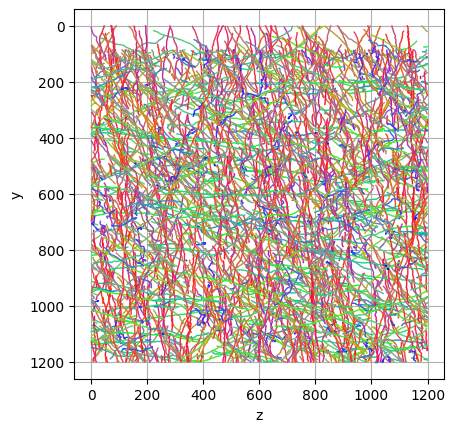

In [5]:
fig, ax = navis.plot2d(skeleton, color=color_map, view=('z', '-y'))
plt.savefig(figures_path / 'skels_ori.pdf')
plt.show()

## ODF grid (spatial decomposition)
Load pre-computed bounding-box positions and per-box mean vectors, then display an ODF for each spatial tile.

In [6]:
bboxes = pickle.load(open(data_path / 'box_pos_5x10.pkl', 'rb'))
mv_grid = pickle.load(open(data_path / 'mean_vectors_5x10.pkl', 'rb'))
print(f'Grid: {len(bboxes)} tiles, {len(mv_grid)} mean-vector sets')

Grid: 50 tiles, 50 mean-vector sets


/var/folders/0c/k95xpw3j5k9_9qd8wbmg4z240000gp/T/ipykernel_62341/3017890737.py:20: UserWarning: Failed to use notebook backend "client": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


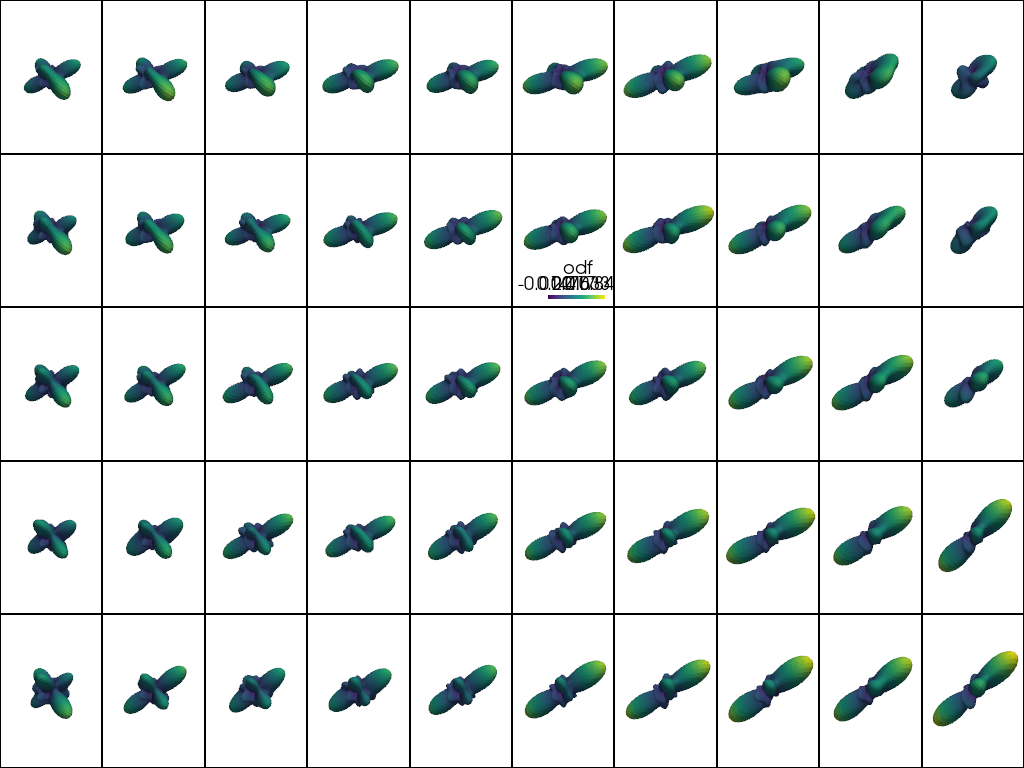

In [7]:
n_rows, n_cols, degree = 5, 10, 6
pv.set_jupyter_backend('client')
plotter = pv.Plotter(shape=(n_rows, n_cols))

for i, box in enumerate(bboxes):
    row, col = box[1], box[2]
    odf_tile = ODF(degree=degree)
    odf_tile.fit(mv_grid[i])

    sph = make_sphere(3000)
    vals = odf_tile.to_sphere(sph) * 3
    faces = sph.faces.copy()
    new_faces = np.concatenate((np.full(faces.shape[0], 3).reshape(-1, 1), faces), axis=1)
    mesh = pv.PolyData(sph.vertices * vals[:, None], faces=new_faces)
    mesh['odf'] = vals
    plotter.subplot(row, col)
    plotter.add_mesh(mesh, scalars='odf')

plotter.link_views()
plotter.show()